## customer revenue concentration - first week
Simple notebook-style analysis with synthetic data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from analytics_decision_kit.sample_data import create_demo_orders
from analytics_decision_kit.customer_analysis import run_customer_analysis

# later: maybe add plotly charts, but first get numbers right


### create demo orders
Synthetic data.

In [2]:
orders = create_demo_orders(n_customers=5000, n_orders=18000, seed=42)

# check raw dataset, always good practice
orders.head()


,order_id,customer_id,order_date,category,brand,revenue
0,O00000096,C001950,2025-01-01,Accessories,Brand D,381.77
1,O00000790,C004782,2025-01-01,Bags,Brand B,796.89
2,O00000834,C002230,2025-01-01,Bags,Brand A,221.45
3,O00000928,C001355,2025-01-01,Ready-to-wear,Brand A,753.51
4,O00001093,C003008,2025-01-01,Ready-to-wear,Brand D,244.18


In [5]:
# quick EDA
#orders.shape
#orders.info()
#orders['revenue'].describe()


count    18000.000000
mean       481.860741
std        531.180828
min          8.100000
25%        174.990000
50%        320.360000
75%        590.317500
max      11764.400000
Name: revenue, dtype: float64

### run first analysis

In [6]:
results = run_customer_analysis(orders)

customer_df = results['customer_metrics']
decile_df = results['decile_summary']
pareto_df = results['pareto_summary']

customer_df.head()


,customer_id,first_order_date,last_order_date,orders,revenue,avg_order_value,customer_age_days,revenue_per_day,is_repeat_customer,segment
0,C004142,2025-01-06,2025-12-25,93,41183.62,442.834624,354,116.337910,True,High Value
1,C004223,2025-01-04,2025-12-31,66,29695.11,449.925909,362,82.030691,True,High Value
2,C003142,2025-01-04,2025-12-16,46,26826.65,583.188043,347,77.310231,True,High Value
3,C000847,2025-01-01,2025-12-27,52,26060.65,501.166346,361,72.190166,True,High Value
4,C003305,2025-01-06,2025-12-25,45,23478.12,521.736000,354,66.322373,True,High Value


### revenue concentration

In [7]:
decile_df


,decile,customers,revenue,avg_revenue_per_customer,revenue_share,cumulative_revenue,cumulative_revenue_share
0,1,401,3411288.99,8506.955087,0.393300,3411288.99,0.393300
1,2,401,1603381.77,3998.458279,0.184860,5014670.76,0.578160
2,3,401,1096094.86,2733.403641,0.126373,6110765.62,0.704533
3,4,401,814189.01,2030.396534,0.093871,6924954.63,0.798404
4,5,401,595447.31,1484.906010,0.068651,7520401.94,0.867056
5,6,401,435315.00,1085.573566,0.050189,7955716.94,0.917245
6,7,401,314516.83,784.331247,0.036262,8270233.77,0.953507
7,8,401,214143.44,534.023541,0.024689,8484377.21,0.978196
8,9,401,131937.50,329.021197,0.015212,8616314.71,0.993408
9,10,401,57178.63,142.590100,0.006592,8673493.34,1.000000


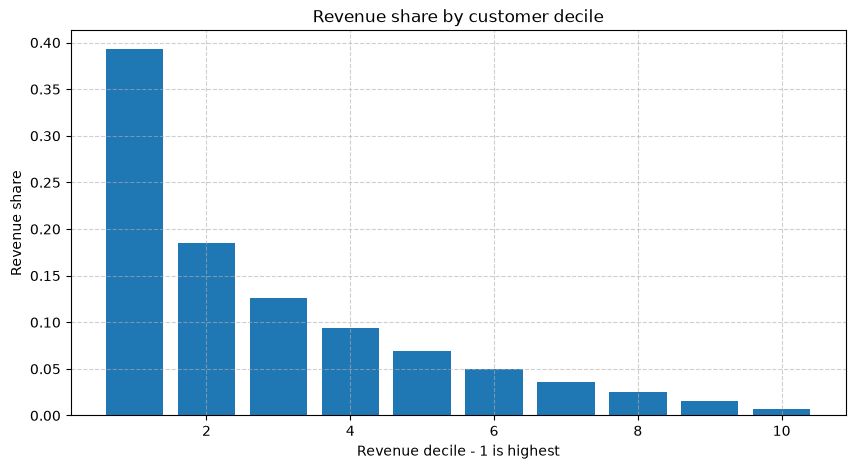

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(decile_df['decile'], decile_df['revenue_share'])
plt.xlabel('Revenue decile - 1 is highest')
plt.ylabel('Revenue share')
plt.title('Revenue share by customer decile')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### executive summary

In [9]:
print(results['summary_text'])


Customer base analyzed: 4,010 customers.
Top 10% of customers generate 39.3% of revenue.
Repeat customers generate 94.5% of revenue and have 6.0x higher revenue per customer than one-time buyers.
Revenue concentration is moderate.
Repeat customers materially outperform one-time buyers.
Recommended next step: inspect activation, retention and category penetration by segment.
